In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [286]:
df=pd.read_csv('customer_logistic.csv')
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,-99999.000000,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,NaN,4.032673,3.0,female,Dhaka,0


### Part A — Data Understanding + Cleaning + Encoding

In [287]:
summary=pd.DataFrame(columns=['column_name','data_type','missing_count','missing_percent'])

In [288]:

summary['column_name']=df.columns
summary['data_type']=df.dtypes.values
summary['missing_count']=df.isna().sum().values
summary['missing_percent']=summary['missing_count']/df.shape[0]*100
summary

,column_name,data_type,missing_count,missing_percent
0,age,float64,8,3.636364
1,income,object,9,4.090909
2,time_spent,float64,0,0.000000
3,visits,float64,0,0.000000
4,gender,object,0,0.000000
5,city,object,12,5.454545
6,buy,int64,0,0.000000


In [289]:

# Total number of rows
total_rows = df.shape[0]

# Create summary DataFrame
summary = pd.DataFrame({
    'column_name': df.columns,
    'data_type': df.dtypes.values,
    'missing_count': df.isnull().sum().values,
    'missing_percent': (df.isnull().sum().values / total_rows) * 100
})

# Display summary
summary

,column_name,data_type,missing_count,missing_percent
0,age,float64,8,3.636364
1,income,object,9,4.090909
2,time_spent,float64,0,0.000000
3,visits,float64,0,0.000000
4,gender,object,0,0.000000
5,city,object,12,5.454545
6,buy,int64,0,0.000000


In [290]:
total_rows

220

In [291]:
df.shape

(220, 7)

In [292]:
df.isna().sum()

,0
age,8
income,9
time_spent,0
visits,0
gender,0
city,12
buy,0


In [293]:
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,-99999.000000,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,NaN,4.032673,3.0,female,Dhaka,0


In [294]:
df=df.replace(to_replace=[-99999,-88888,'NA','?'],value=np.nan)

In [295]:
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,NaN,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,NaN,4.032673,3.0,female,Dhaka,0


In [296]:
df.isnull().sum()

,0
age,8
income,9
time_spent,6
visits,0
gender,4
city,12
buy,0


In [297]:
df.dtypes

,0
age,float64
income,object
time_spent,float64
visits,float64
gender,object
city,object
buy,int64


In [298]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna("IDK", inplace=True)

In [299]:
df.isnull().sum()

,0
age,0
income,0
time_spent,0
visits,0
gender,0
city,0
buy,0


In [300]:
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,8.345798,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,IDK,4.032673,3.0,female,Dhaka,0


In [301]:
df1=df.copy()
df2=df.copy()

In [302]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1['city']=le.fit_transform(df['city'])
df1.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,8.345798,2.0,female,1,0
1,34.0,66k,11.885847,0.0,female,1,0
2,45.0,46k,1.921230,5.0,female,0,0
3,35.0,97k,10.974633,4.0,female,2,1
4,31.0,IDK,4.032673,3.0,female,1,0


In [303]:
df2=pd.get_dummies(df2,columns=['city'])
df2.head()

,age,income,time_spent,visits,gender,buy,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto
0,43.0,97k,8.345798,2.0,female,0,False,True,False,False,False
1,34.0,66k,11.885847,0.0,female,0,False,True,False,False,False
2,45.0,46k,1.921230,5.0,female,0,True,False,False,False,False
3,35.0,97k,10.974633,4.0,female,1,False,False,True,False,False
4,31.0,IDK,4.032673,3.0,female,0,False,True,False,False,False


In [304]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Encoding Mapping:", mapping)

Label Encoding Mapping: {'Calgary': np.int64(0), 'Dhaka': np.int64(1), 'Edmonton': np.int64(2), 'IDK': np.int64(3), 'Toronto': np.int64(4)}


## Part B — Visualization + Simple Statistics

In [305]:
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,8.345798,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,IDK,4.032673,3.0,female,Dhaka,0


In [306]:
df['buy'].value_counts()

,count
buy,
0,145
1,75


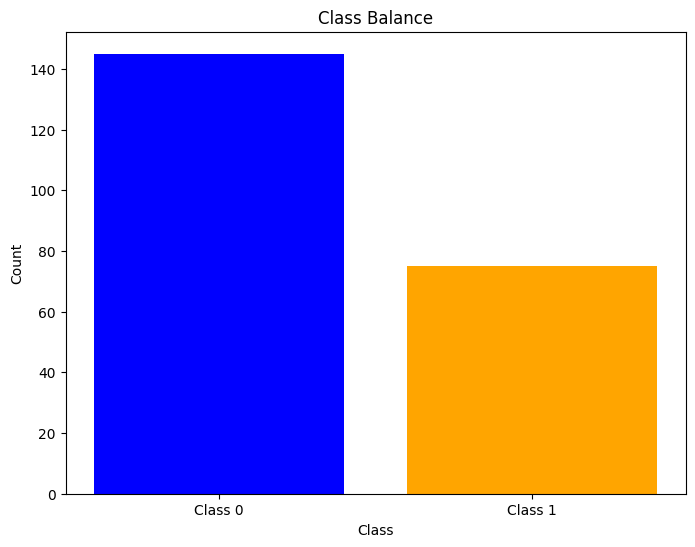

In [307]:
plt.figure(figsize=(8, 6))
plt.bar(['Class 0', 'Class 1'], df['buy'].value_counts(), color=['blue', 'orange'])
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

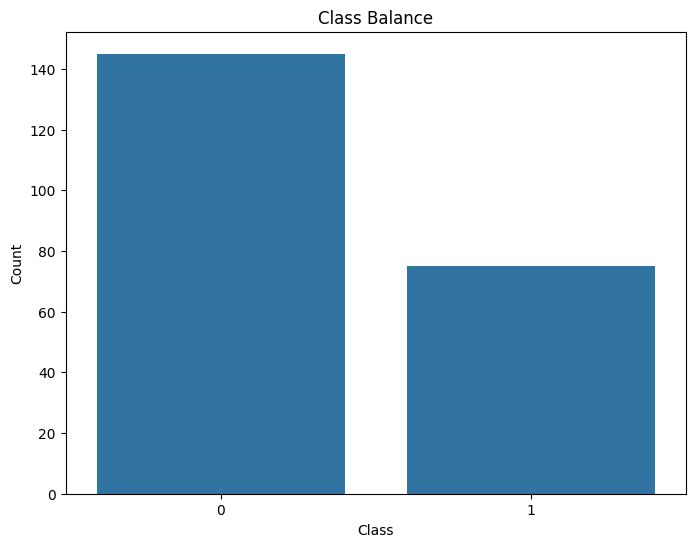

In [308]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='buy')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

(array([145.,  75.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

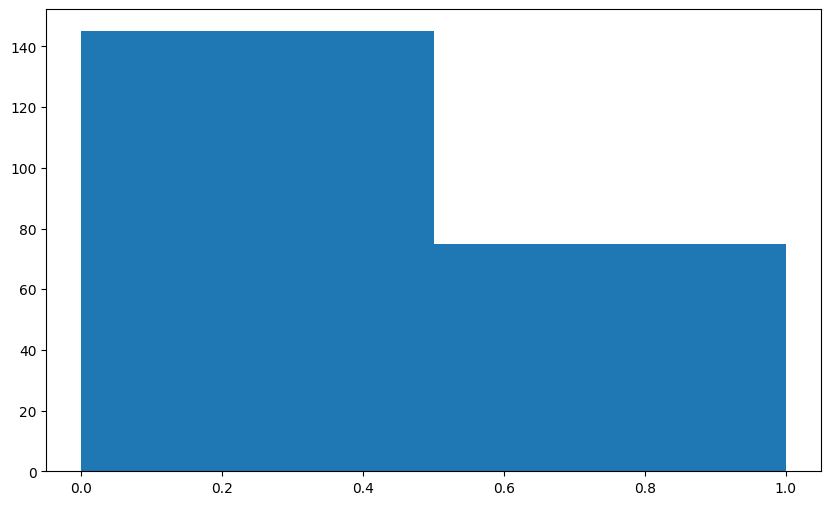

In [309]:
plt.figure(figsize=(10, 6))
plt.hist(df['buy'],bins=2)

buy
0    145
1     75
Name: count, dtype: int64


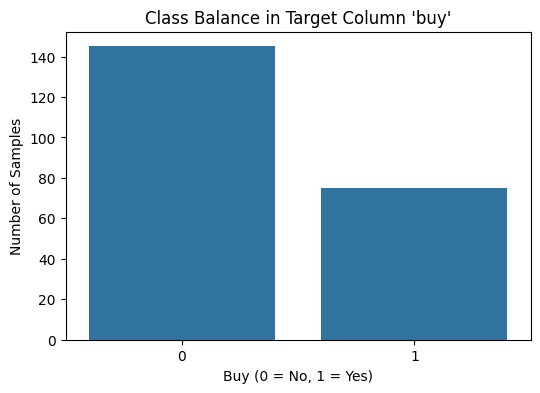

In [310]:
# Count samples in each class
class_counts = df['buy'].value_counts()
print(class_counts)

# Bar chart / count plot
plt.figure(figsize=(6,4))
sns.countplot(x='buy', data=df)
plt.title("Class Balance in Target Column 'buy'")
plt.xlabel("Buy (0 = No, 1 = Yes)")
plt.ylabel("Number of Samples")
plt.show()

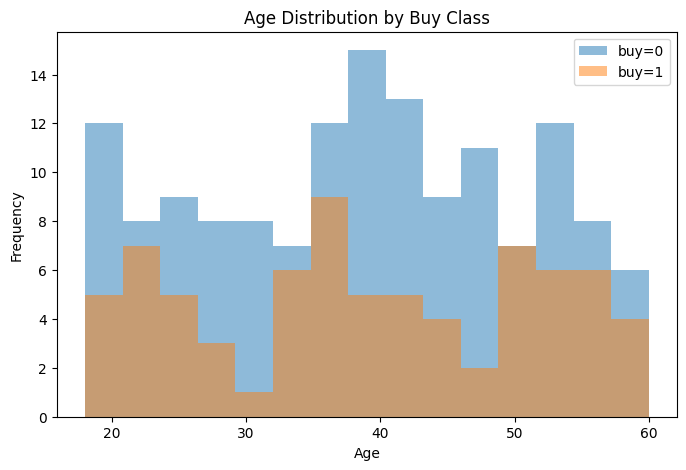

In [311]:
plt.figure(figsize=(8,5))

# Rows where buy=0
plt.hist(df.loc[df['buy']==0, 'age'], bins=15, alpha=0.5, label='buy=0')

# Rows where buy=1
plt.hist(df.loc[df['buy']==1, 'age'], bins=15, alpha=0.5, label='buy=1')

plt.title("Age Distribution by Buy Class")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

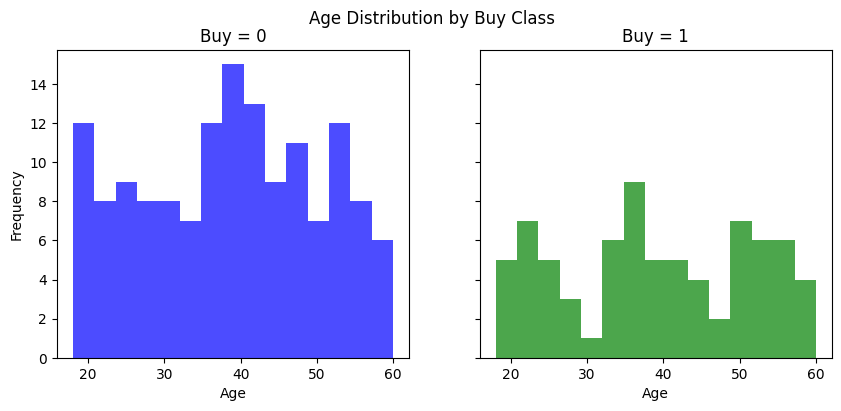

In [312]:
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
axes[0].hist(df.loc[df['buy']==0, 'age'], bins=15, color='blue', alpha=0.7)
axes[0].set_title("Buy = 0")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

axes[1].hist(df.loc[df['buy']==1, 'age'], bins=15, color='green', alpha=0.7)
axes[1].set_title("Buy = 1")
axes[1].set_xlabel("Age")

plt.suptitle("Age Distribution by Buy Class")
plt.show()

In [313]:
df['income'].value_counts()

,count
income,
66k,10
IDK,9
72k,8
75k,8
62k,8
...,...
34k,1
49k,1
104k,1


In [314]:
df=df.drop(df[df['income']=='IDK'].index)

In [315]:
df['income'].value_counts()

,count
income,
66k,10
72k,8
75k,8
62k,8
74k,8
...,...
34k,1
49k,1
104k,1


In [316]:
df['income'] = df['income'].str.replace('k','').astype(float) * 1000
df['income'] = df['income'].astype(int)

In [317]:
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97000,8.345798,2.0,female,Dhaka,0
1,34.0,66000,11.885847,0.0,female,Dhaka,0
2,45.0,46000,1.921230,5.0,female,Calgary,0
3,35.0,97000,10.974633,4.0,female,Edmonton,1
5,30.0,42000,5.748861,3.0,male,Dhaka,0


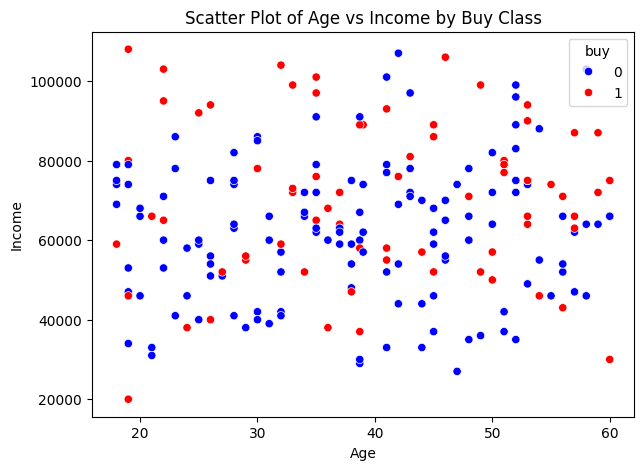

In [318]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='income', hue='buy', data=df, palette={0:'blue', 1:'red'})
plt.title("Scatter Plot of Age vs Income by Buy Class")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

## Part C — Logistic Regression Model

In [319]:
df.head()


,age,income,time_spent,visits,gender,city,buy
0,43.0,97000,8.345798,2.0,female,Dhaka,0
1,34.0,66000,11.885847,0.0,female,Dhaka,0
2,45.0,46000,1.921230,5.0,female,Calgary,0
3,35.0,97000,10.974633,4.0,female,Edmonton,1
5,30.0,42000,5.748861,3.0,male,Dhaka,0


In [320]:
df1=pd.get_dummies(df,columns=['city'],dtype=int)
df1.head()
df1=pd.get_dummies(df1,columns=['gender'],dtype=int)
df1.head()


,age,income,time_spent,visits,buy,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
0,43.0,97000,8.345798,2.0,0,0,1,0,0,0,0,1,0
1,34.0,66000,11.885847,0.0,0,0,1,0,0,0,0,1,0
2,45.0,46000,1.921230,5.0,0,1,0,0,0,0,0,1,0
3,35.0,97000,10.974633,4.0,1,0,0,1,0,0,0,1,0
5,30.0,42000,5.748861,3.0,0,0,1,0,0,0,0,0,1


In [321]:
x=df1.drop('buy',axis=1)
y=df1['buy']

In [322]:
x.head()

,age,income,time_spent,visits,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
0,43.0,97000,8.345798,2.0,0,1,0,0,0,0,1,0
1,34.0,66000,11.885847,0.0,0,1,0,0,0,0,1,0
2,45.0,46000,1.921230,5.0,1,0,0,0,0,0,1,0
3,35.0,97000,10.974633,4.0,0,0,1,0,0,0,1,0
5,30.0,42000,5.748861,3.0,0,1,0,0,0,0,0,1


In [323]:
y.head()

,buy
0,0
1,0
2,0
3,1
5,0


In [324]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()


In [325]:
numeric_cols = x.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
X_scaled = x.copy()
X_scaled[numeric_cols] = scaler.fit_transform(x[numeric_cols])

In [326]:
x.head()

,age,income,time_spent,visits,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
0,43.0,97000,8.345798,2.0,0,1,0,0,0,0,1,0
1,34.0,66000,11.885847,0.0,0,1,0,0,0,0,1,0
2,45.0,46000,1.921230,5.0,1,0,0,0,0,0,1,0
3,35.0,97000,10.974633,4.0,0,0,1,0,0,0,1,0
5,30.0,42000,5.748861,3.0,0,1,0,0,0,0,0,1


In [327]:
X_scaled.head()

,age,income,time_spent,visits,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
0,0.595238,0.875000,0.523800,0.222222,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.380952,0.522727,0.770219,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.642857,0.295455,0.076593,0.555556,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.404762,0.875000,0.706790,0.444444,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,0.285714,0.250000,0.343030,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [328]:
from sklearn.model_selection import train_test_split as tts

In [332]:
x_train,x_test,y_train,y_test=tts(X_scaled,y,test_size=0.2,random_state=42)

In [333]:
x_train

,age,income,time_spent,visits,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
133,0.357143,0.602273,0.677186,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113,0.000000,0.556818,0.803542,0.222222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
72,0.452381,0.488636,0.434078,0.222222,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
87,0.500000,0.784091,0.918072,0.111111,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
102,0.023810,0.295455,0.790621,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
111,0.547619,0.147727,0.339347,0.222222,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
15,0.023810,0.375000,0.576196,0.333333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
96,0.500000,0.477273,0.474621,0.555556,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
186,0.000000,0.613636,0.598215,0.222222,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [334]:
y_train

,buy
133,1
113,0
72,0
87,1
102,1
...,...
111,0
15,0
96,0
186,0


In [335]:
x_test

,age,income,time_spent,visits,city_Calgary,city_Dhaka,city_Edmonton,city_IDK,city_Toronto,gender_IDK,gender_female,gender_male
31,0.142857,0.204545,0.146730,0.555556,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
180,0.047619,0.522727,0.446997,0.111111,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
146,0.404762,0.670455,0.939936,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
78,0.928571,0.522727,0.750658,0.333333,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
63,0.190476,0.352273,0.401753,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
217,0.380952,0.363636,0.571944,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
47,0.190476,0.625000,0.124449,0.222222,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
190,0.690476,0.613636,0.696571,0.666667,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10,0.666667,0.511364,0.611345,0.111111,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
105,0.190476,0.840909,0.568790,0.444444,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [336]:
y_test

,buy
31,1
180,0
146,0
78,1
63,0
217,1
47,0
190,0
10,0
105,1


In [337]:
from sklearn.linear_model import LogisticRegression

In [338]:
model=LogisticRegression()

In [339]:
model.fit(x_train,y_train)

LogisticRegression()

In [341]:
pred=model.predict(x_test)

In [342]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.5581395348837209

In [344]:
# Take first sample from test set
sample = x_test.iloc[0:1]

# Input values
print("Input values:")
print(sample)

# Predicted class (0/1)
pred_class = model.predict(sample)[0]
print("Predicted class:", pred_class)

# Predicted probability of class 1
pred_prob = model.predict_proba(sample)[0][1]
print("Predicted probability of class 1:", pred_prob)

# Actual class
actual_class = y_test.iloc[0]
print("Actual class:", actual_class)

Input values:
         age    income  time_spent    visits  city_Calgary  city_Dhaka  \
31  0.142857  0.204545     0.14673  0.555556           0.0         1.0   

    city_Edmonton  city_IDK  city_Toronto  gender_IDK  gender_female  \
31            0.0       0.0           0.0         0.0            1.0   

    gender_male  
31          0.0  
Predicted class: 0
Predicted probability of class 1: 0.14409908869069013
Actual class: 1
